In [9]:
#JAI GANESH JAI DURGAMA OM NAMHA SHIVAYA


import pandas as pd
import numpy as np

df=pd.read_csv(r"C:\Users\GANGADHAR\OneDrive\Desktop\scm_pro\supply_chain_data_expanded.csv")

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# remove duplicates
df = df.drop_duplicates()

# fix duplicate lead time column
if "lead_times" in df.columns:
    df = df.rename(columns={"lead_times": "lead_time_alt"})

# split column types
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

# fill missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

# create features
if "manufacturing_costs" in df.columns and "shipping_costs" in df.columns:
    df["total_cost"] = df["manufacturing_costs"] + df["shipping_costs"]

if "revenue_generated" in df.columns:
    df["profit"] = df["revenue_generated"] - df["total_cost"]

if "lead_time" in df.columns:
    df["delay_risk"] = (df["lead_time"] > df["lead_time"].median()).astype(int)

if "stock_levels" in df.columns and "number_of_products_sold" in df.columns:
    df["stock_risk"] = (df["stock_levels"] < df["number_of_products_sold"]).astype(int)

# check result
print(df.shape)
print(df.isnull().sum())

# save file
df.to_csv("cleaned_supply_chain_data.csv", index=False)

(2100, 28)
product_type               0
sku                        0
price                      0
availability               0
number_of_products_sold    0
revenue_generated          0
customer_demographics      0
stock_levels               0
lead_time_alt              0
order_quantities           0
shipping_times             0
shipping_carriers          0
shipping_costs             0
supplier_name              0
location                   0
lead_time                  0
production_volumes         0
manufacturing_lead_time    0
manufacturing_costs        0
inspection_results         0
defect_rates               0
transportation_modes       0
routes                     0
costs                      0
total_cost                 0
profit                     0
delay_risk                 0
stock_risk                 0
dtype: int64



--- Demand by Product ---
product_type
skincare     428307
haircare     353102
cosmetics    272019
Name: number_of_products_sold, dtype: int64

--- Revenue by Product ---
product_type
skincare     2.203802e+07
haircare     1.621429e+07
cosmetics    1.342451e+07
Name: revenue_generated, dtype: float64

--- Supplier Performance ---
               lead_time  defect_rates
supplier_name                         
Supplier 5     31.024213      2.509478
Supplier 1     31.234300      2.453017
Supplier 2     31.332547      2.412556
Supplier 4     31.559113      2.550986
Supplier 3     32.451467      2.543007

--- Cost by Transport Mode ---
transportation_modes
Air     64.982017
Rail    65.549506
Sea     66.222873
Road    66.428335
Name: total_cost, dtype: float64

--- Delay Risk ---
delay_risk
0    1070
1    1030
Name: count, dtype: int64

--- Stock Risk ---
stock_risk
1    1923
0     177
Name: count, dtype: int64


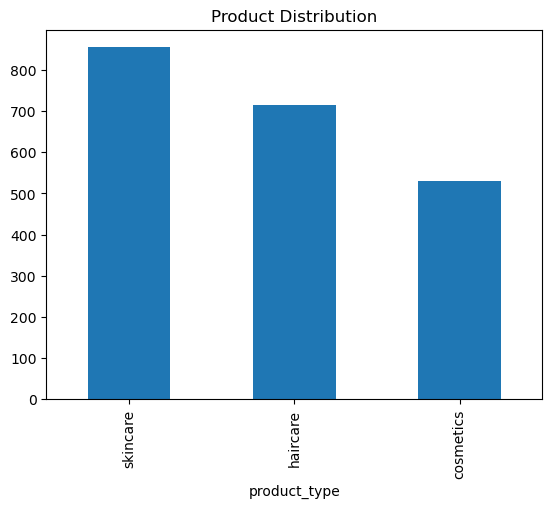

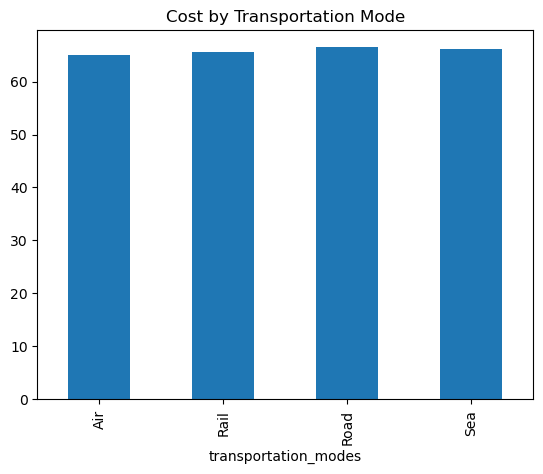

In [10]:
# ===============================
# EDA START
# ===============================

# 1. Demand Analysis
print("\n--- Demand by Product ---")
print(df.groupby("product_type")["number_of_products_sold"].sum().sort_values(ascending=False))

# 2. Revenue Analysis
print("\n--- Revenue by Product ---")
print(df.groupby("product_type")["revenue_generated"].sum().sort_values(ascending=False))

# 3. Supplier Performance
print("\n--- Supplier Performance ---")
print(df.groupby("supplier_name")[["lead_time","defect_rates"]].mean().sort_values(by="lead_time"))

# 4. Cost Analysis
print("\n--- Cost by Transport Mode ---")
print(df.groupby("transportation_modes")["total_cost"].mean().sort_values())

# 5. Risk Analysis
print("\n--- Delay Risk ---")
print(df["delay_risk"].value_counts())

print("\n--- Stock Risk ---")
print(df["stock_risk"].value_counts())

# ===============================
# VISUAL PART
# ===============================

import matplotlib.pyplot as plt

# 6. Product Distribution
df["product_type"].value_counts().plot(kind="bar")
plt.title("Product Distribution")
plt.show()

# 7. Cost by Transport
df.groupby("transportation_modes")["total_cost"].mean().plot(kind="bar")
plt.title("Cost by Transportation Mode")
plt.show()

# ===============================
# EDA END
# ===============================

In [20]:
# better features
df['demand_stock_ratio'] = df['number_of_products_sold'] / (df['stock_levels'] + 1)
df['cost_per_unit'] = df['total_cost'] / (df['number_of_products_sold'] + 1)
df['price_stock_interaction'] = df['price'] * df['stock_levels']

In [21]:
# ===============================
# MACHINE LEARNING - DEMAND PREDICTION
# Using Multiple Linear Regression
# Goal: Predict number_of_products_sold
# ===============================

# DEMAND PREDICTION

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# features & target
X = df[['price', 'stock_levels', 'lead_time', 'shipping_costs',
        'manufacturing_costs', 'demand_stock_ratio', 'price_stock_interaction']]

y = df['number_of_products_sold']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

# model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# prediction
y_pred = model.predict(X_test_scaled)

# evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# add to dataframe
df['demand_new'] = model.predict(scaler_reg.transform(X))


MAE: 248.03434773202954
R2 Score: 0.06294641462180683


In [26]:
# DELAY PREDICTION (FIXED - NO LEAKAGE)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# 🔹 create delay risk (based on multiple factors)
df['delay_risk'] = np.where(
    (df['lead_time'] > df['lead_time'].mean()) |
    (df['shipping_costs'] > df['shipping_costs'].mean()),
    1, 0
)

# 🔹 feature engineering
df['demand_stock_ratio'] = df['number_of_products_sold'] / (df['stock_levels'] + 1)

# 🔹 IMPORTANT: remove lead_time from features (avoid leakage)
X_cls = df[['price', 'stock_levels', 'shipping_costs',
            'manufacturing_costs', 'demand_stock_ratio']]

y_cls = df['delay_risk']

# 🔹 split
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# 🔹 scaling
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

# 🔹 model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 🔹 prediction
y_pred_cls = clf.predict(X_test_scaled)

# 🔹 evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_cls))

# 🔹 add predictions to dataset
df['delay_risk_after'] = clf.predict(scaler_clf.transform(X_cls))

Accuracy: 0.7547619047619047


In [3]:
# ===============================
# SIMULATION + DECISION + SCENARIO (FINAL)
# ===============================

import pandas as pd

# load data
df = pd.read_csv("cleaned_supply_chain_data.csv")

# create copy
sim_df = df.copy()

# -------------------------------
# 1. DEMAND SPIKE (5% increase)
# -------------------------------
sim_df['demand_new'] = sim_df['number_of_products_sold'] * 1.05

# -------------------------------
# 2. DELAY INCREASE (+3 days)
# -------------------------------
sim_df['lead_time_new'] = sim_df['lead_time'] + 3

# delay risk
sim_df['delay_risk_after'] = (
    sim_df['lead_time_new'] > sim_df['lead_time'].mean()
).astype(int)

# -------------------------------
# 3. COST INCREASE (10%)
# -------------------------------
sim_df['total_cost_new'] = sim_df['total_cost'] * 1.1

# profit after cost increase
sim_df['profit_after'] = sim_df['revenue_generated'] - sim_df['total_cost_new']

# -------------------------------
# 4. DECISION ENGINE
# -------------------------------
def get_decision(row):
    ratio = row['demand_new'] / (row['stock_levels'] + 1)

    if ratio > 5:
        return "Reorder Stock"
    elif row['delay_risk_after'] == 1:
        return "Change Supplier"
    elif row['profit_after'] < row['profit']:
        return "Reduce Cost"
    else:
        return "Normal"

sim_df['decision'] = sim_df.apply(get_decision, axis=1)

# -------------------------------
# 5. SCENARIO CREATION (MULTIPLE)
# -------------------------------
def assign_scenario(row):
    ratio = row['demand_new'] / (row['stock_levels'] + 1)

    if ratio > 5:
        return "High Demand"
    elif row['delay_risk_after'] == 1:
        return "High Delay"
    elif row['profit_after'] < row['profit']:
        return "Cost Increase"
    else:
        return "Normal"

sim_df['scenario'] = sim_df.apply(assign_scenario, axis=1)

# -------------------------------
# 6. CHECK DISTRIBUTION (IMPORTANT)
# -------------------------------
print("\nScenario Distribution:\n", sim_df['scenario'].value_counts())
print("\nDecision Distribution:\n", sim_df['decision'].value_counts())

# -------------------------------
# 7. SAVE FINAL OUTPUT
# -------------------------------
sim_df.to_csv("final_supply_chain_output.csv", index=False)

print("\n✅ CSV Exported Successfully!")


Scenario Distribution:
 scenario
High Demand      1137
High Delay        524
Cost Increase     439
Name: count, dtype: int64

Decision Distribution:
 decision
Reorder Stock      1137
Change Supplier     524
Reduce Cost         439
Name: count, dtype: int64

✅ CSV Exported Successfully!


In [6]:
# ===============================
# FINAL DATASET FOR SQL + POWER BI
# ===============================

import pandas as pd

sim_df = pd.read_csv("final_supply_chain_output.csv")

# add original vs new demand
sim_df['original_demand'] = sim_df['number_of_products_sold']
sim_df['demand_increase'] = sim_df['demand_new'] - sim_df['original_demand']

# DO NOT recreate scenario (already exists)
# sim_df['scenario'] = sim_df.apply(assign_scenario, axis=1) ❌ REMOVE if already done

# select useful columns
final_df = sim_df[[
    'product_type',
    'price',
    'stock_levels',
    'original_demand',
    'demand_new',
    'demand_increase',
    'delay_risk_after',
    'profit',
    'profit_after',
    'decision',
    'scenario'
]]

# preview
print(final_df.head())

# export CLEAN dataset
final_df.to_csv("final_supply_chain_output.csv", index=False)

print("\n✅ Final Clean CSV Exported Successfully!")

  product_type      price  stock_levels  original_demand  demand_new  \
0     haircare  69.808006            58              802      842.10   
1     skincare  14.843523            53              736      772.80   
2     haircare  11.319683             1                8        8.40   
3     skincare  61.163343            23               83       87.15   
4     skincare   4.805496             5              871      914.55   

   demand_increase  delay_risk_after       profit  profit_after  \
0            40.10                 1  8612.760341   8607.836696   
1            36.80                 0  7417.566722   7413.233387   
2             0.40                 0  9539.007127   9535.132877   
3             4.15                 0  7729.482116   7725.746685   
4            43.55                 0  2590.549443   2580.953872   

        decision       scenario  
0  Reorder Stock    High Demand  
1  Reorder Stock    High Demand  
2    Reduce Cost  Cost Increase  
3    Reduce Cost  Cost Incre

In [7]:
final_df.to_csv("final_supply_chain_output.csv", index=False)